In [7]:
!pip install transformers
!pip install torch
!pip install jiwer
!pip install librosa

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 3.6 MB/s  0:00:00

   ---- ----------------------------------- 1/9 [soxr]
   ------------- -------------------------- 3/9 [standard-sunau]
   ---------------------- ----------------- 5/9 [soundfile]
   -------------------------- ------------- 6/9 [pooch]
   -------------------------- ------------- 6/9 [pooch]
   -------------------------- ------------- 6/9 [pooch]
   -------------------------- ------------- 6/9 [pooch]
   ------------------------------- -------- 7/9 [audioread]
   ------------------------------- -------- 7/9 [audioread]
   ----------------------------------- ---- 8/9 [librosa]
   ----------------------------------- ---- 8/9 [librosa]
   ----------------------------------- ---- 8/9 [librosa]
   ----------------------------------- ---- 8/9 [librosa]
   ----------------------

In [10]:
!pip install librosa

In [13]:
from transformers import pipeline
import librosa

pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base"
)

audio, sr = librosa.load("audio/hakka3.wav", sr=16000)

result = pipe(audio, return_timestamps=True)

print(result["text"])

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits pr

 Please call Staler, ask her to bring these things with her from the store. Six scoops of a fresh snow piece, five thick slabs of blue cheese, and maybe a snake for her bright bob. We also need a small plastic snake and a big toy for the kids. She can scoop these themes into three red bags, and we will go meet her Wednesday at the the translation.


In [25]:
from transformers import pipeline
import pandas as pd
import jiwer
import librosa

pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base"
)

meta = pd.read_csv("metadata.csv")

results = []

for index, row in meta.iterrows():

    audio_path = f"audio/{row['file_name']}.wav"

    audio, sr = librosa.load(audio_path, sr=16000)

    result = pipe(
        audio,
        return_timestamps=True,
        generate_kwargs={"language": "en"}
    )

    prediction = result["text"]

    wer = jiwer.wer(
        row["ground_truth"],
        prediction
    )

    results.append({
        "speaker_id": row["speaker_id"],
        "accent_group": row["accent_group"],
        "ground_truth": row["ground_truth"],  
        "prediction": prediction,
        "wer": wer
    })

df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)

print("Done.")

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Done.


In [26]:
df.groupby("accent_group")["wer"].mean()

accent_group
chinese_L1         0.222222
standard_native    0.152174
Name: wer, dtype: float64

In [17]:
print(df[["accent_group","prediction"]])

       accent_group                                         prediction
0        chinese_L1   Please call Staler, ask her to bring these th...
1        chinese_L1   Police Gaustella, ask her to breathe the thin...
2        chinese_L1   Please close that up, et cetera to bring thes...
3        chinese_L1   Please call Stella, ask her to bring these th...
4        chinese_L1   Peacecore Steyla asked her to bring this thin...
5        chinese_L1   Please call Stella, ask her to bring these th...
6   standard_native   Please call Stella, ask her to bring these th...
7   standard_native   Please call a stellar. Ask her to bring these...
8   standard_native   Please call Stella, ask her to bring these th...
9   standard_native   Please call Stella, ask her to bring these th...
10  standard_native   Please call Stella. Ask her to bring these th...
11  standard_native   Please call Stella, ask her to bring these th...


In [27]:
df.head()

,speaker_id,accent_group,ground_truth,prediction,wer
0,C1,chinese_L1,Please call Stella. Ask her to bring these thi...,"Please call Staler, ask her to bring these th...",0.188406
1,C2,chinese_L1,Please call Stella. Ask her to bring these thi...,"Police Gaustella, ask her to breathe the thin...",0.246377
2,C3,chinese_L1,Please call Stella. Ask her to bring these thi...,"Please close that up, et cetera to bring thes...",0.202899
3,C4,chinese_L1,Please call Stella. Ask her to bring these thi...,"Please call Stella, ask her to bring these th...",0.144928
4,C5,chinese_L1,Please call Stella. Ask her to bring these thi...,Peacecore Steyla asked her to bring this thin...,0.347826


In [28]:
df_sorted = df.sort_values("wer", ascending=False)
df_sorted.head()

,speaker_id,accent_group,ground_truth,prediction,wer
4,C5,chinese_L1,Please call Stella. Ask her to bring these thi...,Peacecore Steyla asked her to bring this thin...,0.347826
1,C2,chinese_L1,Please call Stella. Ask her to bring these thi...,"Police Gaustella, ask her to breathe the thin...",0.246377
7,E2,standard_native,Please call Stella. Ask her to bring these thi...,Please call a stellar. Ask her to bring these...,0.217391
9,E4,standard_native,Please call Stella. Ask her to bring these thi...,"Please call Stella, ask her to bring these th...",0.217391
2,C3,chinese_L1,Please call Stella. Ask her to bring these thi...,"Please close that up, et cetera to bring thes...",0.202899


In [29]:
df_sorted = df.sort_values("wer", ascending=False)

row = df_sorted.iloc[0]

truth = row["ground_truth"]
prediction = row["prediction"]

print("Truth:", truth)
print("Prediction:", prediction)

from jiwer import process_words
res = process_words(truth, prediction)

print("WER:", res.wer)
print("Substitutions:", res.substitutions)
print("Deletions:", res.deletions)
print("Insertions:", res.insertions)

Truth: Please call Stella. Ask her to bring these things with her from the store: Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack for her brother Bob. We also need a small plastic snake and a big toy frog for the kids. She can scoop these things into three red bags, and we will go meet her Wednesday at the train station.
Prediction:  Peacecore Steyla asked her to bring this thing with her from the store, six spoons of fresh snow piece, five stick slabs of blue cheese, and maybe a stick for her, for her brother, both. We also need a small plastic snake and a big toe fork for the kiss. She can spoon this thing into three web baths and we will go meet her Wednesday at train station.
WER: 0.34782608695652173
Substitutions: 20
Deletions: 2
Insertions: 2


In [30]:
df["fail_30"] = df["wer"] > 0.30
df.groupby("accent_group")["fail_30"].mean()

accent_group
chinese_L1         0.166667
standard_native    0.000000
Name: fail_30, dtype: float64

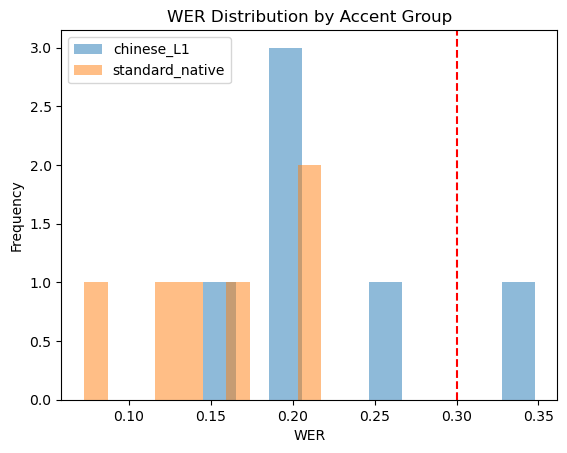

In [31]:
import matplotlib.pyplot as plt

for group in df["accent_group"].unique():
    subset = df[df["accent_group"] == group]
    plt.hist(subset["wer"], alpha=0.5, label=group)

plt.axvline(0.30, color='red', linestyle='--')
plt.legend()
plt.title("WER Distribution by Accent Group")
plt.xlabel("WER")
plt.ylabel("Frequency")
plt.show()

In [32]:
from jiwer import process_words

stats = []

for _, row in df.iterrows():
    res = process_words(row["ground_truth"], row["prediction"])
    stats.append({
        "accent_group": row["accent_group"],
        "sub": res.substitutions,
        "del": res.deletions,
        "ins": res.insertions
    })

err_df = pd.DataFrame(stats)

print(err_df.groupby("accent_group").sum())

                 sub  del  ins
accent_group                  
chinese_L1        77   10    5
standard_native   52    5    6


In [33]:
df.groupby("accent_group")["wer"].agg(["mean","std"])

,mean,std
accent_group,,
chinese_L1,0.222222,0.069605
standard_native,0.152174,0.057790


In [34]:
thresholds = [0.20, 0.25, 0.30, 0.35]

for t in thresholds:
    df[f"fail_{t}"] = df["wer"] > t
    print("\nThreshold:", t)
    print(df.groupby("accent_group")[f"fail_{t}"].mean())


Threshold: 0.2
accent_group
chinese_L1         0.666667
standard_native    0.333333
Name: fail_0.2, dtype: float64

Threshold: 0.25
accent_group
chinese_L1         0.166667
standard_native    0.000000
Name: fail_0.25, dtype: float64

Threshold: 0.3
accent_group
chinese_L1         0.166667
standard_native    0.000000
Name: fail_0.3, dtype: float64

Threshold: 0.35
accent_group
chinese_L1         0.0
standard_native    0.0
Name: fail_0.35, dtype: float64


In [37]:
df[["accent_group","wer"]].to_json("wer_data.json", orient="records")